In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [30]:
dataset=pd.read_csv(r"C:\Users\beher\OneDrive\Desktop\ML\classification\logit classification.csv")

In [31]:
dataset.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [32]:
x=dataset.iloc[:,[2,3]].values
y=dataset.iloc[:,-1].values

In [33]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [34]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [35]:
from sklearn.linear_model import LogisticRegression
logit = LogisticRegression()
logit.fit(x_train,y_train)
y_pred=logit.predict(x_test)

In [36]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

In [37]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[57  1]
 [ 5 17]]


In [38]:
ac=accuracy_score(y_test,y_pred)
ac

0.925

In [39]:

cr=classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.92      0.98      0.95        58
           1       0.94      0.77      0.85        22

    accuracy                           0.93        80
   macro avg       0.93      0.88      0.90        80
weighted avg       0.93      0.93      0.92        80



In [40]:
bias=logit.score(x_train,y_train)
bias

0.821875

In [41]:
varience=logit.score(x_test,y_test)
varience

0.925

In [42]:
dataset1=pd.read_csv(r"C:\Users\beher\Downloads\Future prediction1.csv")

In [43]:
d2=dataset1.copy()

In [44]:
d2.head()

,User ID,Gender,Age,EstimatedSalary
0,15724611,Male,45,60000
1,15725621,Female,79,64000
2,15725622,Male,23,78000
3,15720611,Female,34,45000
4,15588044,Male,29,76000


In [45]:
dataset1=dataset1.iloc[:,[2,3]].values

In [46]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [47]:
m=sc.fit_transform(dataset1)

In [48]:
y_pred=pd.DataFrame()


In [49]:
d2['y_pred']=logit.predict(m)

In [50]:
d2

,User ID,Gender,Age,EstimatedSalary,y_pred
0,15724611,Male,45,60000,0
1,15725621,Female,79,64000,1
2,15725622,Male,23,78000,0
3,15720611,Female,34,45000,0
4,15588044,Male,29,76000,0
5,15746039,Female,70,89000,1
6,15704887,Male,86,120000,1
7,15746009,Female,46,23000,0
8,15876009,Male,32,70000,0
9,15886009,Female,100,90000,1


In [51]:
d2.to_csv("final.csv")

In [52]:
from sklearn.metrics import roc_auc_score,roc_curve
y_pred_prod=logit.predict_proba(x_test)[:,1]
auc_score=roc_auc_score(y_test,y_pred_prod)
auc_score

np.float64(0.9764890282131661)

In [54]:
fpr,tpr,thresholds=roc_curve(y_test,y_pred_prod)

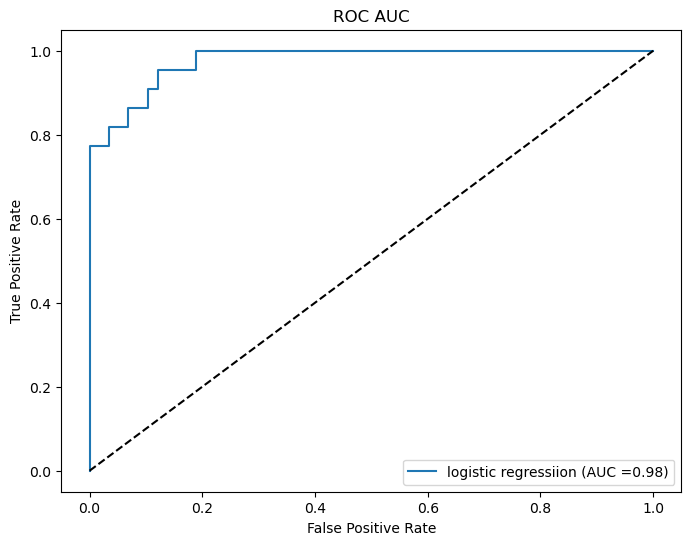

In [55]:
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f"logistic regressiion (AUC ={auc_score:.2f})")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC AUC")
plt.legend(loc="lower right")
plt.show()